##### 분석 목표 : 타이타닉 호에 탑승한 승객들의 생존여부 예측
###### 생존에 영향을 끼친 주요 요인은 무엇인가?

###### PassengerId: 승객 ID (각 승객을 고유하게 식별하는 번호)
###### Survived: 생존 여부 (0: 사망, 1: 생존)
###### Pclass: 객실 등급 (1: 1등석, 2: 2등석, 3: 3등석)
###### Name: 이름
###### Sex: 성별
###### Age: 나이
###### SibSp: 함께 탑승한 형제자매 및 배우자 수
###### Parch: 함께 탑승한 부모 및 자녀 수
###### Ticket: 티켓 번호
###### Fare: 요금
###### Cabin: 객실 번호
###### Embarked: 탑승 항구 (C: 셰르부르, Q: 퀸스타운, S: 사우샘프턴)

#### 1. train.csv 파일을 불러와 데이터 탐색(EDA)
- 데이터의 기본 구조와 내용을 확인

### 내 코드

In [2]:
import pandas as pd

train = pd.read_csv("./datasets/titanic/train.csv")

# info 메소드로 결측값 분포 확인
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### GPT

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
결측값 비율이 있는 열:
 Age         19.865320
Cabin       77.104377
Embarked     0.224467
dtype: float64


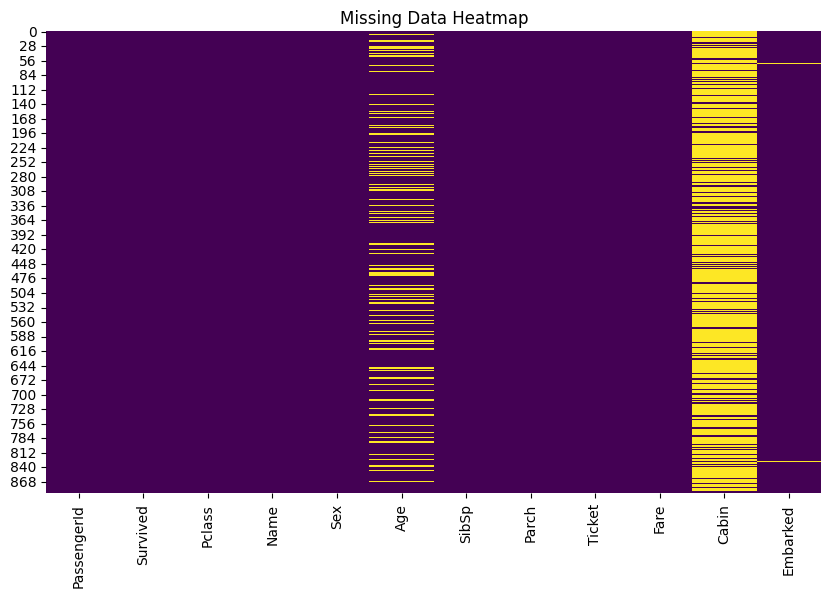

성별 분포:
 Sex
male      577
female    314
Name: count, dtype: int64

탑승지 분포:
 Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터 불러오기
train = pd.read_csv("./datasets/titanic/train.csv")

# 데이터 정보 확인
train.info()

# 결측값 비율 확인
missing_data = train.isnull().mean() * 100
print("결측값 비율이 있는 열:\n", missing_data[missing_data > 0])

# 결측값 분포 시각화
plt.figure(figsize=(10, 6))
sns.heatmap(train.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Heatmap")
plt.show()

# 수치형 데이터 통계 요약
train.describe()

# 범주형 변수의 값 분포 확인
print("성별 분포:\n", train['Sex'].value_counts())
print("\n탑승지 분포:\n", train['Embarked'].value_counts())

# 데이터 앞부분 미리 보기
train.head()

In [4]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
train.isnull().mean()

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64

###### 기초 작업 (필수 단계)
###### - 데이터 구조 이해: info()로 데이터 유형, 결측값 확인.
###### - 기초 통계 확인: describe()로 수치형 변수의 분포 확인.
###### - 범주형 변수의 분포 확인: value_counts()로 주요 범주형 변수의 값 분포 확인.
###### - 데이터 샘플 미리보기: head()로 데이터의 실제 값을 파악.

#### 2. 데이터 전처리 (Data Preprocessing)
- 데이터를 모델링에 적합한 형태로 준비

##### 데이터 전처리 단계
###### - 결측값 처리
###### - 데이터 타입 변환
###### - 범주형 데이터 인코딩
###### - 불필요한 열 제거
###### - 스케일링 및 정규화 (필요 시)

In [ ]:
# Cabin(객실번호) 삭제

train.drop()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C
